### 06 Align plaques TIFF image to Xenium coordinates

This notebook aligns `morphology.ome.tiff` to the Xenium spatial coordinates in `05_scvi.h5ad`, writes QC overlays, optionally applies manual landmark correction, segments plaque-like signal, and assigns each cell to its nearest plaque.

Run the cells from top to bottom. After the first run, inspect `qc_initial_morphology_xenium_overlay.png`, `qc_final_morphology_xenium_overlay.png`, and `qc_plaque_segmentation.png` in the working directory. If the overlay needs correction, fill the generated `manual_landmarks.csv` and rerun the landmark/alignment cells.


#### Imports

In [27]:
import json
import os
import xml.etree.ElementTree as ET
from pathlib import Path
from typing import Any
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import tifffile as tiff
from scipy.spatial import cKDTree
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label, regionprops_table
from skimage.morphology import (
    binary_closing,
    binary_opening,
    disk,
    remove_small_holes,
    remove_small_objects,
)
from skimage.transform import AffineTransform, estimate_transform


#### Paths

In [28]:
WORKING_DIRECTORY = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment")
INPUT_DIR = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI")
MORPHOLOGY_PATH = Path('/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif').expanduser()

H5AD_PATH = INPUT_DIR / "05_scvi.h5ad"
ALIGNED_H5AD_PATH = WORKING_DIRECTORY / "05_scvi_with_morphology_alignment.h5ad"
PLAQUE_H5AD_PATH = WORKING_DIRECTORY / "05_scvi_with_plaque_distances.h5ad"
LANDMARK_TEMPLATE_PATH = WORKING_DIRECTORY / "manual_landmarks_template.csv"
LANDMARK_PATH = WORKING_DIRECTORY / "manual_landmarks.csv"

WORKING_DIRECTORY.mkdir(parents=True, exist_ok=True)
os.chdir(WORKING_DIRECTORY)

print(f"Working directory: {Path.cwd()}")
print(f"Input h5ad: {H5AD_PATH}")
print(f"Morphology image: {MORPHOLOGY_PATH}")

assert H5AD_PATH.exists(), f"Missing h5ad: {H5AD_PATH}"
assert MORPHOLOGY_PATH.exists(), f"Missing morphology image: {MORPHOLOGY_PATH}"


Working directory: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment
Input h5ad: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI/05_scvi.h5ad
Morphology image: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif


#### Settings to tune

In [29]:
# Xenium cell coordinates are usually in microns. Change to "pixel" only if
# your h5ad coordinates are already full-resolution image pixels.
COORDINATE_UNITS = "micron"

# Use a pyramid level for plotting/segmentation to keep memory reasonable.
# 0 is full resolution. 1 or 2 is usually enough for QC.
DISPLAY_LEVEL = 2

# If the OME-TIFF is multi-channel and one channel is plaque/amyloid signal,
# set its 0-based channel index here. None uses a max projection over channels.
PLAQUE_CHANNEL_INDEX = None
RUN_PLAQUE_SEGMENTATION = True

# Plaque segmentation thresholds. Tune after inspecting qc_plaque_segmentation.png.
PLAQUE_THRESHOLD_MODE = "absolute"
PLAQUE_ABSOLUTE_THRESHOLD = 2975.0
PLAQUE_SMOOTH_SIGMA = 0.0
PLAQUE_THRESHOLD_MULTIPLIER = 1.0
MIN_PLAQUE_AREA_UM2 = 25.0
MAX_HOLE_AREA_UM2 = 25.0
PLAQUE_OPENING_RADIUS_PX = 1
PLAQUE_CLOSING_RADIUS_PX = 2

# Distance from plaque centroid to call a cell plaque-proximal.
# Units follow COORDINATE_UNITS; for Xenium this should be microns.
PLAQUE_NEIGHBOR_RADIUS = 50.0

# Start with "similarity"; use "affine" only if QC shows true shear/stretch.
LANDMARK_TRANSFORM_TYPE = "similarity"


#### Coordinate helpers

In [30]:
def get_xenium_coordinates(adata) -> tuple[pd.DataFrame, str]:
    """Return a two-column dataframe of spatial coordinates from AnnData."""
    if "spatial" in adata.obsm:
        coords = np.asarray(adata.obsm["spatial"], dtype=float)
        if coords.ndim != 2 or coords.shape[1] < 2:
            raise ValueError('adata.obsm["spatial"] exists but is not n x 2.')
        xy = pd.DataFrame(coords[:, :2], index=adata.obs_names, columns=["x", "y"])
        return xy, 'adata.obsm["spatial"]'

    obs_pairs = [
        ("x_centroid", "y_centroid"),
        ("x_centroid_um", "y_centroid_um"),
        ("center_x", "center_y"),
        ("x", "y"),
    ]
    for x_col, y_col in obs_pairs:
        if {x_col, y_col}.issubset(adata.obs.columns):
            xy = adata.obs[[x_col, y_col]].astype(float)
            xy.columns = ["x", "y"]
            return xy, f'adata.obs[["{x_col}", "{y_col}"]]'

    raise KeyError(
        "Could not find spatial coordinates. Expected obsm['spatial'] or "
        "obs columns like x_centroid/y_centroid."
    )


#### OME-TIFF helpers

In [31]:
def _get_yx_shape(shape: tuple[int, ...], axes: str | None) -> tuple[int, int]:
    if axes and len(axes) == len(shape):
        axes = axes.upper()
        if "Y" in axes and "X" in axes:
            return int(shape[axes.index("Y")]), int(shape[axes.index("X")])
    if len(shape) < 2:
        raise ValueError(f"Cannot infer YX shape from {shape}.")
    return int(shape[-2]), int(shape[-1])


def _maybe_float(value: str | None) -> float | None:
    if value is None:
        return None
    try:
        return float(value)
    except ValueError:
        return None


def _maybe_int(value: str | None) -> int | None:
    if value is None:
        return None
    try:
        return int(value)
    except ValueError:
        return None


def parse_ome_pixels(ome_xml: str | None) -> dict[str, Any]:
    """Extract useful Pixels attributes from OME XML."""
    if not ome_xml:
        return {}

    root = ET.fromstring(ome_xml)
    if root.tag.startswith("{"):
        namespace = root.tag.split("}")[0].strip("{")
        pixels = root.find(".//ome:Pixels", {"ome": namespace})
    else:
        pixels = root.find(".//Pixels")

    if pixels is None:
        return {}

    attrs = pixels.attrib
    return {
        "size_x": _maybe_int(attrs.get("SizeX")),
        "size_y": _maybe_int(attrs.get("SizeY")),
        "size_c": _maybe_int(attrs.get("SizeC")),
        "physical_size_x": _maybe_float(attrs.get("PhysicalSizeX")),
        "physical_size_y": _maybe_float(attrs.get("PhysicalSizeY")),
        "physical_size_x_unit": attrs.get("PhysicalSizeXUnit"),
        "physical_size_y_unit": attrs.get("PhysicalSizeYUnit"),
    }


def inspect_ome_tiff(path: Path) -> dict[str, Any]:
    """Inspect the OME-TIFF pyramid without loading the full image."""
    with tiff.TiffFile(path) as tif:
        series = tif.series[0]
        levels = getattr(series, "levels", None) or [series]
        ome_pixels = parse_ome_pixels(tif.ome_metadata)

        level_records = []
        for i, level in enumerate(levels):
            axes = getattr(level, "axes", getattr(series, "axes", ""))
            shape = tuple(int(v) for v in level.shape)
            y, x = _get_yx_shape(shape, axes)
            level_records.append(
                {
                    "level": i,
                    "axes": axes,
                    "shape": shape,
                    "height_px": y,
                    "width_px": x,
                }
            )

    full_y = int(ome_pixels.get("size_y") or level_records[0]["height_px"])
    full_x = int(ome_pixels.get("size_x") or level_records[0]["width_px"])
    for record in level_records:
        record["downsample_y"] = full_y / record["height_px"]
        record["downsample_x"] = full_x / record["width_px"]

    return {
        **ome_pixels,
        "fullres_shape_yx": (full_y, full_x),
        "levels": level_records,
    }


def to_yx_image(
    arr: np.ndarray,
    axes: str | None,
    channel_index: int | None = None,
    projection: str = "max",
) -> np.ndarray:
    """Convert a possibly multi-dimensional OME array to a 2D YX image."""
    arr = np.asarray(arr)
    axes = (axes or "").upper()
    if len(axes) != arr.ndim:
        axes = axes[-arr.ndim:] if len(axes) >= arr.ndim else ""

    if channel_index is not None and "C" in axes:
        c_axis = axes.index("C")
        arr = np.take(arr, channel_index, axis=c_axis)
        axes = axes[:c_axis] + axes[c_axis + 1:]

    if axes and "Y" in axes and "X" in axes:
        y_axis = axes.index("Y")
        x_axis = axes.index("X")
        other_axes = [i for i in range(arr.ndim) if i not in (y_axis, x_axis)]
        arr = np.transpose(arr, other_axes + [y_axis, x_axis])
        if arr.ndim > 2:
            reduce_axes = tuple(range(arr.ndim - 2))
            arr = np.nanmean(arr, axis=reduce_axes) if projection == "mean" else np.nanmax(arr, axis=reduce_axes)
    else:
        arr = np.squeeze(arr)
        if arr.ndim > 2:
            arr = np.nanmax(arr, axis=tuple(range(arr.ndim - 2)))

    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D image after projection, got {arr.shape}.")
    return arr


def read_ome_level(
    path: Path,
    level_index: int,
    channel_index: int | None = None,
    projection: str = "max",
) -> tuple[np.ndarray, dict[str, Any]]:
    with tiff.TiffFile(path) as tif:
        series = tif.series[0]
        levels = getattr(series, "levels", None) or [series]
        level_index = min(level_index, len(levels) - 1)
        level = levels[level_index]
        axes = getattr(level, "axes", getattr(series, "axes", ""))
        arr = level.asarray()

    img = to_yx_image(arr, axes, channel_index=channel_index, projection=projection)
    return img, {
        "level": level_index,
        "axes": axes,
        "raw_shape": tuple(int(v) for v in arr.shape),
        "height_px": int(img.shape[0]),
        "width_px": int(img.shape[1]),
    }


#### Transform and plotting helpers

In [38]:
from skimage import transform as sk_transform
def robust_rescale(img: np.ndarray, lower: float = 1, upper: float = 99.8) -> np.ndarray:
    img = img.astype(float, copy=False)
    lo, hi = np.nanpercentile(img, [lower, upper])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(img, dtype=float)
    return np.clip((img - lo) / (hi - lo), 0, 1)


def make_native_image_to_xenium_transform(
    coordinate_units: str,
    physical_size_x: float,
    physical_size_y: float):
    """Transform full-resolution image pixels to AnnData coordinate units."""
    if coordinate_units == "micron":
        matrix = np.array(
            [[physical_size_x, 0, 0], [0, physical_size_y, 0], [0, 0, 1]],
            dtype=float,
        )
        return sk_transform.AffineTransform(matrix=matrix)
    if coordinate_units == "pixel":
        return sk_transform.AffineTransform()
    raise ValueError('COORDINATE_UNITS must be "micron" or "pixel".')


def fullres_to_level_points(
    xy_fullres_px: np.ndarray,
    fullres_shape_yx: tuple[int, int],
    level_shape_yx: tuple[int, int],
) -> np.ndarray:
    full_y, full_x = fullres_shape_yx
    level_y, level_x = level_shape_yx
    return xy_fullres_px / np.array([full_x / level_x, full_y / level_y])


def level_to_fullres_points(
    xy_level_px: np.ndarray,
    fullres_shape_yx: tuple[int, int],
    level_shape_yx: tuple[int, int],
) -> np.ndarray:
    full_y, full_x = fullres_shape_yx
    level_y, level_x = level_shape_yx
    return xy_level_px * np.array([full_x / level_x, full_y / level_y])


def plot_morphology_overlay(
    img: np.ndarray,
    xy_level_px: np.ndarray,
    title: str,
    output_path: Path,
    sample_n: int = 25000,
    point_size: float = 0.2,
    seed: int = 0,
) -> None:
    rng = np.random.default_rng(seed)
    xy = np.asarray(xy_level_px, dtype=float)
    xy = xy[np.isfinite(xy).all(axis=1)]
    if len(xy) > sample_n:
        xy = xy[rng.choice(len(xy), sample_n, replace=False)]

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(robust_rescale(img), cmap="gray", origin="upper")
    ax.scatter(xy[:, 0], xy[:, 1], s=point_size, c="cyan", alpha=0.35, linewidths=0)
    ax.set_xlim(0, img.shape[1])
    ax.set_ylim(img.shape[0], 0)
    ax.set_aspect("equal")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()
    print(f"Saved: {output_path}")


def json_ready(value: Any) -> Any:
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, tuple):
        return [json_ready(v) for v in value]
    if isinstance(value, list):
        return [json_ready(v) for v in value]
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    return value


#### Landmark correction helpers

In [39]:
def create_landmark_template(path: Path) -> None:
    """Create a blank CSV for optional manual landmark correction."""
    template = pd.DataFrame(
        {
            "name": ["example_landmark_1", "example_landmark_2"],
            "image_x_px": [np.nan, np.nan],
            "image_y_px": [np.nan, np.nan],
            "xenium_x": [np.nan, np.nan],
            "xenium_y": [np.nan, np.nan],
            "notes": [
                "Use full-resolution image pixel coordinates.",
                "If clicked on DISPLAY_LEVEL, multiply by downsample_x/y.",
            ],
        }
    )
    template.to_csv(path, index=False)


def load_manual_landmarks(path: Path) -> pd.DataFrame:
    required = ["image_x_px", "image_y_px", "xenium_x", "xenium_y"]
    if not path.exists():
        return pd.DataFrame(columns=["name", *required, "notes"])
    landmarks = pd.read_csv(path)
    missing = [col for col in required if col not in landmarks.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    return landmarks.dropna(subset=required).copy()


def estimate_image_to_xenium_transform(
    native_transform: AffineTransform,
    landmarks: pd.DataFrame,
    transform_type: str,
) -> tuple[Any, pd.DataFrame, bool]:
    min_points = {"similarity": 2, "affine": 3, "projective": 4}.get(transform_type)
    if min_points is None:
        raise ValueError("transform_type must be similarity, affine, or projective.")

    if len(landmarks) < min_points:
        print(
            f"Using native OME metadata transform. Add at least {min_points} rows "
            f"to {LANDMARK_PATH.name} to fit a {transform_type} correction."
        )
        return native_transform, landmarks, False

    image_points = landmarks[["image_x_px", "image_y_px"]].to_numpy(float)
    xenium_points = landmarks[["xenium_x", "xenium_y"]].to_numpy(float)
    transform = sk_transform.estimate_transform(transform_type, image_points, xenium_points)

    predicted = transform(image_points)
    residual = np.linalg.norm(predicted - xenium_points, axis=1)
    landmarks = landmarks.copy()
    landmarks["residual_xenium_units"] = residual
    print(
        f"Fitted {transform_type} transform with {len(landmarks)} landmarks. "
        f"Mean residual: {residual.mean():.3f} {COORDINATE_UNITS}."
    )
    return transform, landmarks, True


def save_alignment_outputs(
    adata: Any,
    ome_meta: dict[str, Any],
    coordinate_source: str,
    image_to_xenium_transform: Any,
    landmark_transform_used: bool,
    landmarks: pd.DataFrame,
) -> None:
    xform = np.asarray(image_to_xenium_transform.params, dtype=float)
    inverse_xform = np.linalg.inv(xform)

    alignment_json = {
        "morphology_path": str(MORPHOLOGY_PATH),
        "h5ad_path": str(H5AD_PATH),
        "coordinate_source": coordinate_source,
        "coordinate_units": COORDINATE_UNITS,
        "physical_size_x": ome_meta["physical_size_x"],
        "physical_size_y": ome_meta["physical_size_y"],
        "physical_size_x_unit": ome_meta.get("physical_size_x_unit"),
        "physical_size_y_unit": ome_meta.get("physical_size_y_unit"),
        "fullres_shape_yx": ome_meta["fullres_shape_yx"],
        "image_to_xenium_matrix": xform,
        "xenium_to_image_matrix": inverse_xform,
        "landmark_transform_type": LANDMARK_TRANSFORM_TYPE,
        "landmark_transform_used": landmark_transform_used,
        "manual_landmark_path": str(LANDMARK_PATH),
    }

    if len(landmarks) and "residual_xenium_units" in landmarks:
        landmarks.to_csv(WORKING_DIRECTORY / "manual_landmarks_with_residuals.csv", index=False)
        alignment_json["landmark_residual_mean"] = float(landmarks["residual_xenium_units"].mean())
        alignment_json["landmark_residual_max"] = float(landmarks["residual_xenium_units"].max())

    with open(WORKING_DIRECTORY / "morphology_alignment_metadata.json", "w") as handle:
        json.dump(json_ready(alignment_json), handle, indent=2)

    np.savez(
        WORKING_DIRECTORY / "morphology_alignment_transform.npz",
        image_to_xenium_matrix=xform,
        xenium_to_image_matrix=inverse_xform,
    )

    adata.uns["morphology_alignment"] = {
        "morphology_path": str(MORPHOLOGY_PATH),
        "coordinate_source": coordinate_source,
        "coordinate_units": COORDINATE_UNITS,
        "physical_size_x": float(ome_meta["physical_size_x"]),
        "physical_size_y": float(ome_meta["physical_size_y"]),
        "fullres_shape_yx": np.asarray(ome_meta["fullres_shape_yx"], dtype=int),
        "image_to_xenium_matrix": xform,
        "xenium_to_image_matrix": inverse_xform,
        "landmark_transform_used": bool(landmark_transform_used),
    }
    adata.write_h5ad(ALIGNED_H5AD_PATH)
    print(f"Saved aligned AnnData: {ALIGNED_H5AD_PATH}")


#### Plaque segmentation and cell assignment helpers

In [40]:
def segment_plaques(
    plaque_img: np.ndarray,
    image_to_xenium_transform: Any,
    ome_meta: dict[str, Any],
    level_info: dict[str, Any],
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    physical_size_x = float(ome_meta["physical_size_x"])
    physical_size_y = float(ome_meta["physical_size_y"])
    pixel_area_um2 = (
        physical_size_x
        * physical_size_y
        * float(level_info["downsample_x"])
        * float(level_info["downsample_y"])
    )
    min_area_px = max(1, int(np.ceil(MIN_PLAQUE_AREA_UM2 / pixel_area_um2)))
    hole_area_px = max(1, int(np.ceil(MAX_HOLE_AREA_UM2 / pixel_area_um2)))

    plaque_values = plaque_img.astype(float, copy=False)
    if PLAQUE_THRESHOLD_MODE == "absolute":
        threshold = float(PLAQUE_ABSOLUTE_THRESHOLD)
        mask = plaque_values >= threshold
    elif PLAQUE_THRESHOLD_MODE == "otsu":
        if PLAQUE_SMOOTH_SIGMA and PLAQUE_SMOOTH_SIGMA > 0:
            threshold_img = gaussian(
                plaque_values,
                sigma=PLAQUE_SMOOTH_SIGMA,
                preserve_range=True,
            )
        else:
            threshold_img = plaque_values
        threshold = threshold_otsu(threshold_img) * PLAQUE_THRESHOLD_MULTIPLIER
        mask = threshold_img > threshold
    else:
        raise ValueError('PLAQUE_THRESHOLD_MODE must be "absolute" or "otsu".')

    if PLAQUE_OPENING_RADIUS_PX and PLAQUE_OPENING_RADIUS_PX > 0:
        mask = binary_opening(mask, disk(PLAQUE_OPENING_RADIUS_PX))
    if PLAQUE_CLOSING_RADIUS_PX and PLAQUE_CLOSING_RADIUS_PX > 0:
        mask = binary_closing(mask, disk(PLAQUE_CLOSING_RADIUS_PX))
    mask = remove_small_objects(mask, min_size=min_area_px)
    mask = remove_small_holes(mask, area_threshold=hole_area_px)

    print(
        f"Plaque threshold mode: {PLAQUE_THRESHOLD_MODE}; "
        f"threshold={threshold:.3f}; min_area_px={min_area_px}; "
        f"candidate_pixels={int(mask.sum())}"
    )

    labels = label(mask)
    props = pd.DataFrame(
        regionprops_table(
            labels,
            intensity_image=plaque_img,
            properties=["label", "area", "centroid", "bbox", "mean_intensity", "max_intensity"],
        )
    )

    if props.empty:
        return props, mask, labels

    props = props.rename(
        columns={"centroid-0": "centroid_y_level_px", "centroid-1": "centroid_x_level_px"}
    )
    props["plaque_id"] = props["label"].astype(int)
    props["area_um2"] = props["area"] * pixel_area_um2
    props["threshold_mode"] = PLAQUE_THRESHOLD_MODE
    props["threshold"] = float(threshold)

    fullres_xy = level_to_fullres_points(
        props[["centroid_x_level_px", "centroid_y_level_px"]].to_numpy(float),
        tuple(ome_meta["fullres_shape_yx"]),
        (int(level_info["height_px"]), int(level_info["width_px"])),
    )
    props["centroid_x_fullres_px"] = fullres_xy[:, 0]
    props["centroid_y_fullres_px"] = fullres_xy[:, 1]

    xenium_xy = image_to_xenium_transform(fullres_xy)
    props["x_xenium"] = xenium_xy[:, 0]
    props["y_xenium"] = xenium_xy[:, 1]
    return props, mask, labels


def plot_plaque_segmentation(
    plaque_img: np.ndarray,
    mask: np.ndarray,
    plaque_df: pd.DataFrame,
    output_path: Path,
) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(robust_rescale(plaque_img), cmap="gray", origin="upper")
    ax.imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.45, origin="upper")
    if mask.any():
        ax.contour(mask.astype(float), levels=[0.5], colors="cyan", linewidths=0.35)
    if not plaque_df.empty:
        ax.scatter(
            plaque_df["centroid_x_level_px"],
            plaque_df["centroid_y_level_px"],
            s=12,
            c="lime",
            edgecolors="black",
            linewidths=0.4,
        )
    ax.set_xlim(0, plaque_img.shape[1])
    ax.set_ylim(plaque_img.shape[0], 0)
    ax.set_aspect("equal")
    ax.set_title(f"Plaque segmentation: {PLAQUE_THRESHOLD_MODE} threshold {PLAQUE_ABSOLUTE_THRESHOLD:g}")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()
    print(f"Saved: {output_path}")


def assign_cells_to_plaques(adata: Any, xenium_xy: pd.DataFrame, plaque_df: pd.DataFrame) -> None:
    if plaque_df.empty:
        adata.obs["nearest_plaque_id"] = pd.Series(pd.NA, index=adata.obs_names, dtype="Int64")
        adata.obs["nearest_plaque_distance"] = np.nan
        adata.obs["plaque_proximal"] = False
        print("No plaques found; plaque distance columns were filled with NA.")
        return

    plaque_xy = plaque_df[["x_xenium", "y_xenium"]].to_numpy(float)
    cell_xy = xenium_xy[["x", "y"]].to_numpy(float)

    plaque_tree = cKDTree(plaque_xy)
    nearest_distance, nearest_idx = plaque_tree.query(cell_xy, k=1)
    plaque_ids = plaque_df["plaque_id"].to_numpy(int)

    adata.obs["nearest_plaque_id"] = pd.Series(plaque_ids[nearest_idx], index=adata.obs_names, dtype="Int64")
    adata.obs["nearest_plaque_distance"] = nearest_distance
    adata.obs["plaque_proximal"] = nearest_distance <= PLAQUE_NEIGHBOR_RADIUS

    cell_tree = cKDTree(cell_xy)
    plaque_df["n_cells_within_radius"] = [
        len(indices) for indices in cell_tree.query_ball_point(plaque_xy, r=PLAQUE_NEIGHBOR_RADIUS)
    ]


#### Load Xenium object and coordinates

In [41]:
adata = sc.read_h5ad(H5AD_PATH)
xenium_xy, coordinate_source = get_xenium_coordinates(adata)
adata.obsm["xenium_xy"] = xenium_xy[["x", "y"]].to_numpy(float)

print(adata)
print(f"Coordinate source: {coordinate_source}")
print(
    "Coordinate ranges: "
    f"x={xenium_xy['x'].min():.2f}..{xenium_xy['x'].max():.2f}, "
    f"y={xenium_xy['y'].min():.2f}..{xenium_xy['y'].max():.2f}"
)
print("obsm keys:", list(adata.obsm.keys()))


AnnData object with n_obs × n_vars = 158112 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5', 'Topic 6', 'Topic 7', 'Topic 8', 'Topic 9', 'Topic 10', 'Topic 11', 'Topic 12', 'Topic 13', 'Topic 14', 'Topic 15', 'topic', 'batch', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bad_tissue_filtering', 'batch_colors', 'filtering_downsize', 'filtering_image_padding', 'initial_neighborhood_parameters', 'leiden', 'leiden_colors', 'scvi', 'scvi_inp

#### Inspect morphology image and read display level

In [42]:
ome_meta = inspect_ome_tiff(MORPHOLOGY_PATH)
if ome_meta.get("physical_size_x") is None or ome_meta.get("physical_size_y") is None:
    raise ValueError(
        "OME metadata does not contain PhysicalSizeX/Y. "
        "Provide pixel size before converting between microns and pixels."
    )

levels = pd.DataFrame(ome_meta["levels"])
print("OME pyramid levels:")
print(levels.to_string(index=False))
print(
    f"Physical pixel size: {ome_meta['physical_size_x']} x "
    f"{ome_meta['physical_size_y']} {ome_meta.get('physical_size_x_unit') or ''}"
)

display_level = min(DISPLAY_LEVEL, len(ome_meta["levels"]) - 1)
display_img, display_image_info = read_ome_level(
    MORPHOLOGY_PATH, display_level, channel_index=None, projection="max"
)
display_level_info = ome_meta["levels"][display_level]
print(f"Loaded display level {display_level}: {display_img.shape}")


OME pyramid levels:
 level axes              shape  height_px  width_px  downsample_y  downsample_x
     0  ZYX (13, 30724, 39875)      30724     39875      1.000000      1.000000
     1  ZYX (13, 15362, 19937)      15362     19937      2.000000      2.000050
     2  ZYX   (13, 7681, 9968)       7681      9968      4.000000      4.000301
     3  ZYX   (13, 3840, 4984)       3840      4984      8.001042      8.000602
     4  ZYX   (13, 1920, 2492)       1920      2492     16.002083     16.001204
     5  ZYX    (13, 960, 1246)        960      1246     32.004167     32.002408
     6  ZYX     (13, 480, 623)        480       623     64.008333     64.004815
     7  ZYX     (13, 240, 311)        240       311    128.016667    128.215434
Physical pixel size: 0.2125 x 0.2125 µm
Loaded display level 2: (7681, 9968)


#### Metadata-based initial overlay

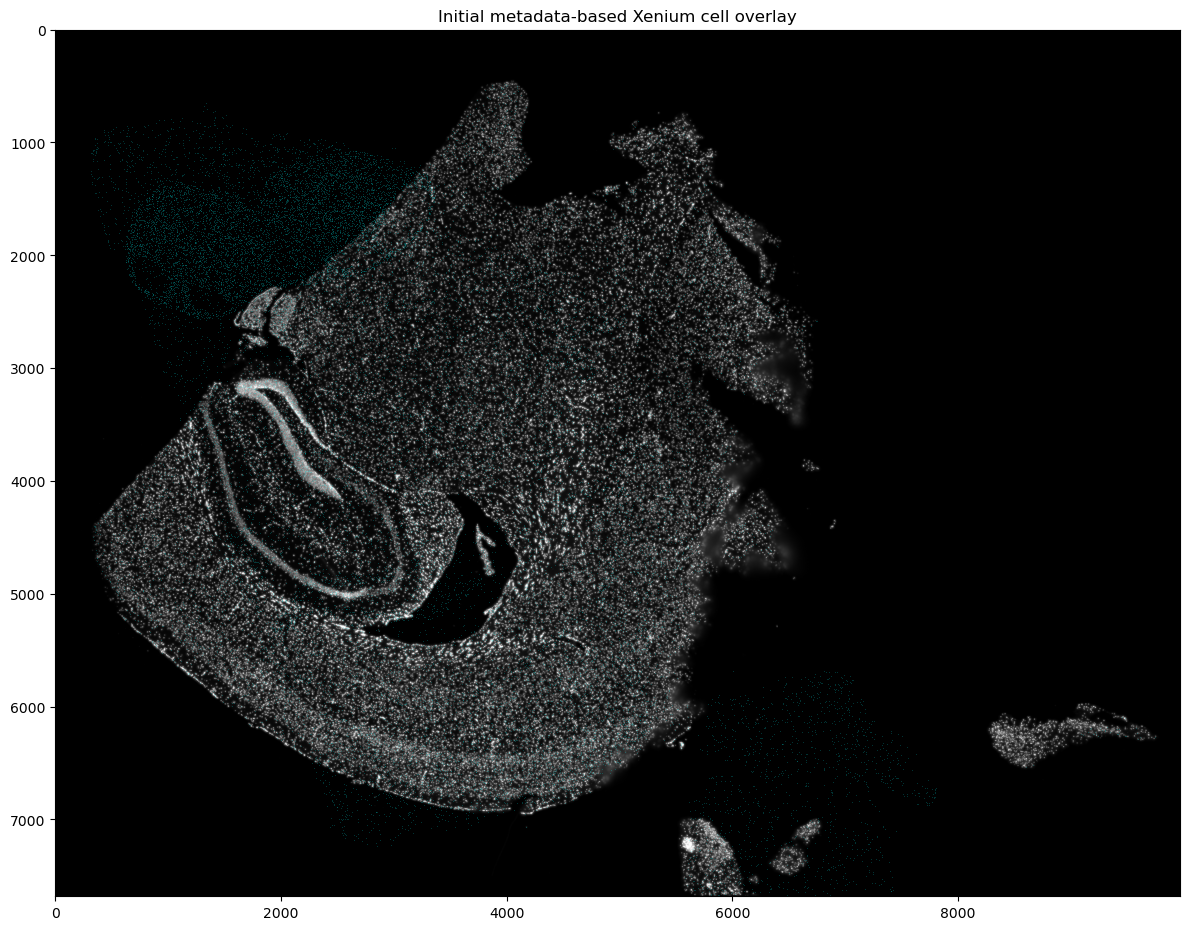

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/qc_initial_morphology_xenium_overlay.png


In [43]:
native_transform = make_native_image_to_xenium_transform(
    COORDINATE_UNITS,
    float(ome_meta["physical_size_x"]),
    float(ome_meta["physical_size_y"]),
)

initial_cell_fullres_px = native_transform.inverse(xenium_xy[["x", "y"]].to_numpy(float))
adata.obsm["morphology_fullres_px_initial"] = initial_cell_fullres_px
initial_cell_level_px = fullres_to_level_points(
    initial_cell_fullres_px,
    tuple(ome_meta["fullres_shape_yx"]),
    (display_image_info["height_px"], display_image_info["width_px"]),
)

plot_morphology_overlay(
    display_img,
    initial_cell_level_px,
    "Initial metadata-based Xenium cell overlay",
    WORKING_DIRECTORY / "qc_initial_morphology_xenium_overlay.png",
)


#### Optional manual landmark correction and save alignment

Created landmark template: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/manual_landmarks_template.csv
Created blank manual landmark file: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/manual_landmarks.csv
Using native OME metadata transform. Add at least 2 rows to manual_landmarks.csv to fit a similarity correction.


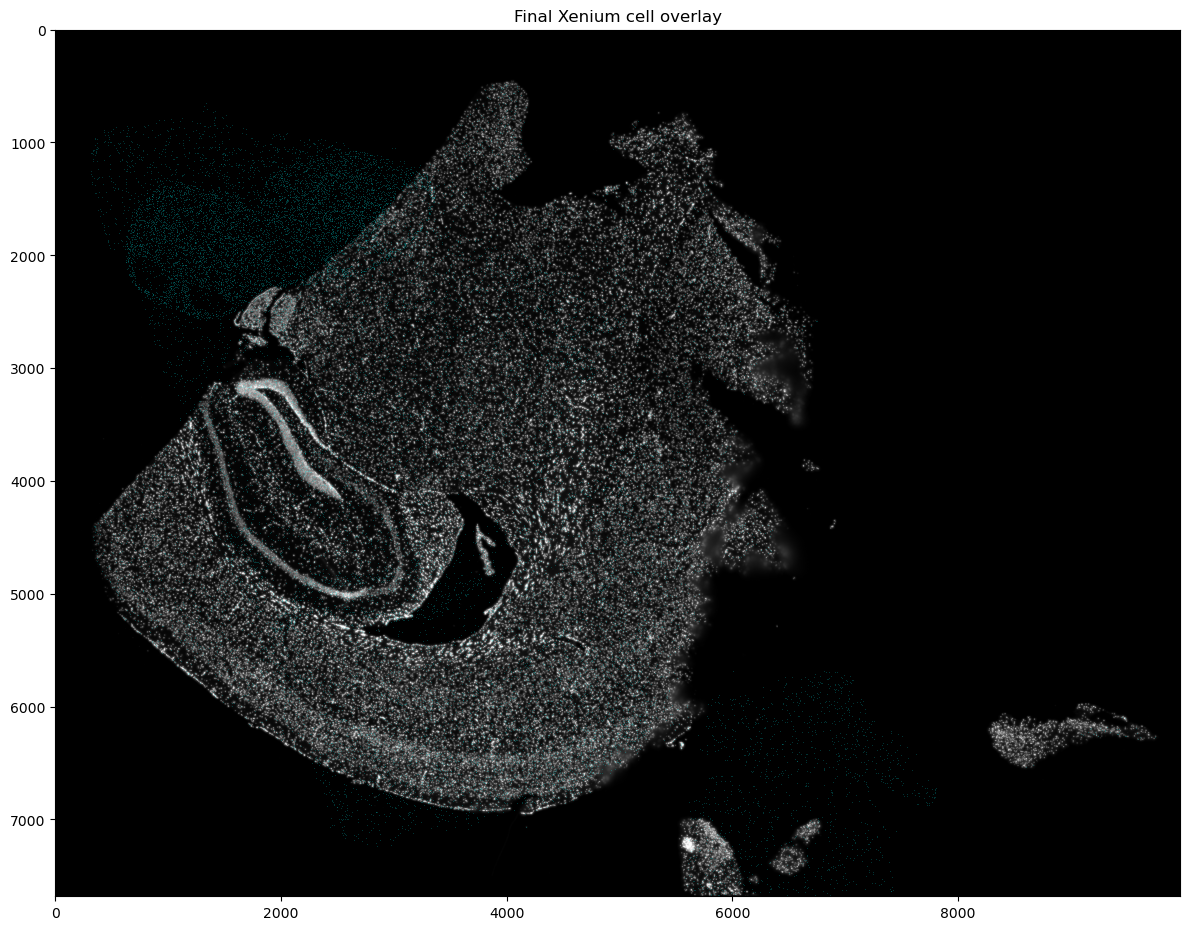

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/qc_final_morphology_xenium_overlay.png
Saved aligned AnnData: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/05_scvi_with_morphology_alignment.h5ad


In [44]:
if not LANDMARK_TEMPLATE_PATH.exists():
    create_landmark_template(LANDMARK_TEMPLATE_PATH)
    print(f"Created landmark template: {LANDMARK_TEMPLATE_PATH}")
if not LANDMARK_PATH.exists():
    create_landmark_template(LANDMARK_PATH)
    print(f"Created blank manual landmark file: {LANDMARK_PATH}")

landmarks = load_manual_landmarks(LANDMARK_PATH)
image_to_xenium_transform, landmarks, landmark_transform_used = estimate_image_to_xenium_transform(
    native_transform, landmarks, LANDMARK_TRANSFORM_TYPE
)

final_cell_fullres_px = image_to_xenium_transform.inverse(xenium_xy[["x", "y"]].to_numpy(float))
adata.obsm["morphology_fullres_px"] = final_cell_fullres_px
final_cell_level_px = fullres_to_level_points(
    final_cell_fullres_px,
    tuple(ome_meta["fullres_shape_yx"]),
    (display_image_info["height_px"], display_image_info["width_px"]),
)

plot_morphology_overlay(
    display_img,
    final_cell_level_px,
    "Final Xenium cell overlay",
    WORKING_DIRECTORY / "qc_final_morphology_xenium_overlay.png",
)

save_alignment_outputs(
    adata,
    ome_meta,
    coordinate_source,
    image_to_xenium_transform,
    landmark_transform_used,
    landmarks,
)


#### Segment plaques and assign nearest plaque to cells

/var/folders/82/6l796mmn2fj1pv97hrt8rh1h0000gp/T/ipykernel_80639/1215408201.py:21: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(PLAQUE_OPENING_RADIUS_PX))
/var/folders/82/6l796mmn2fj1pv97hrt8rh1h0000gp/T/ipykernel_80639/1215408201.py:22: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(PLAQUE_CLOSING_RADIUS_PX))
/var/folders/82/6l796mmn2fj1pv97hrt8rh1h0000gp/T/ipykernel_80639/1215408201.py:23: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while th

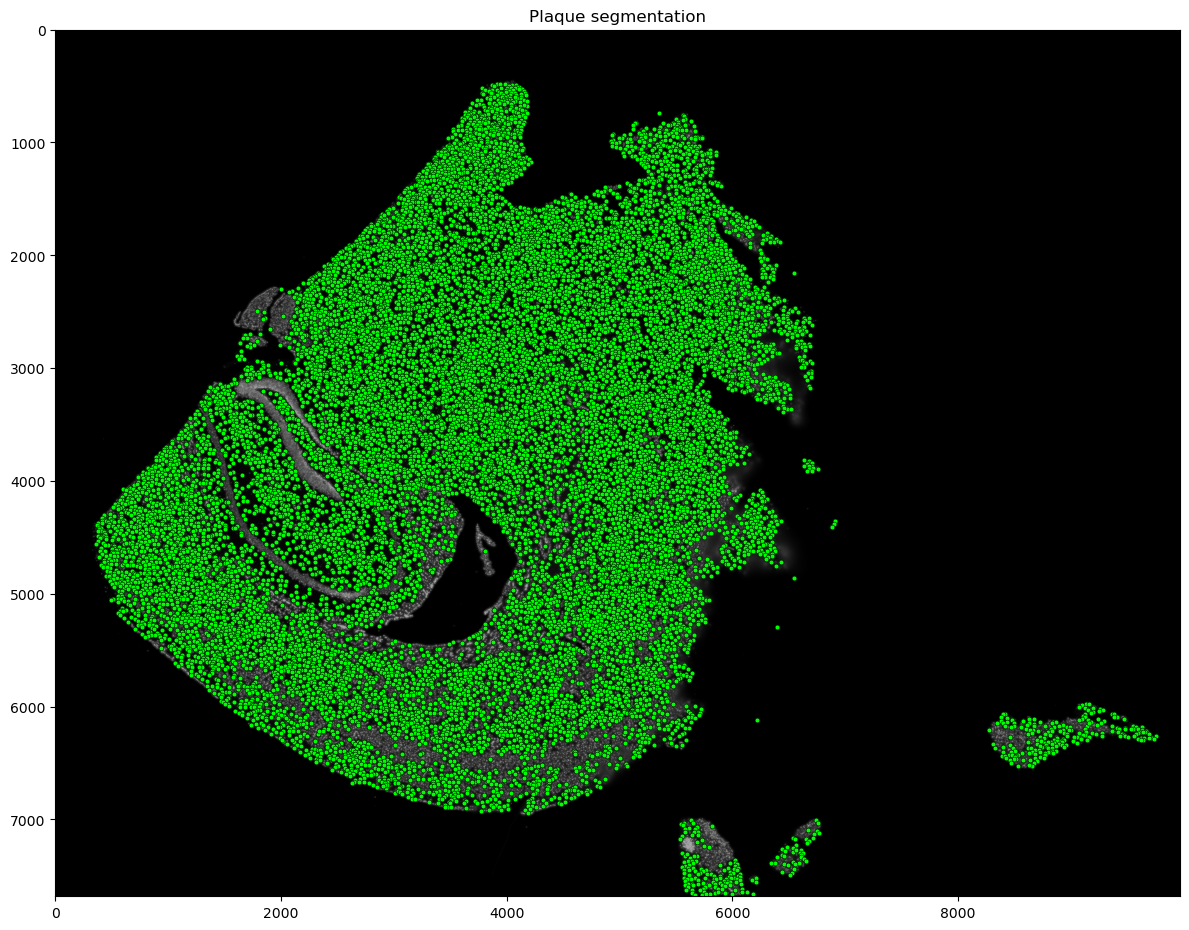

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/qc_plaque_segmentation.png
Saved 16307 segmented plaques to plaques_segmented.csv
Saved plaque-distance AnnData: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/05_scvi_with_plaque_distances.h5ad


In [45]:
if RUN_PLAQUE_SEGMENTATION:
    plaque_img, plaque_image_info = read_ome_level(
        MORPHOLOGY_PATH,
        display_level,
        channel_index=PLAQUE_CHANNEL_INDEX,
        projection="max",
    )
    plaque_level_info = {
        **display_level_info,
        "height_px": plaque_image_info["height_px"],
        "width_px": plaque_image_info["width_px"],
    }

    plaque_df, plaque_mask, plaque_labels = segment_plaques(
        plaque_img, image_to_xenium_transform, ome_meta, plaque_level_info
    )
    plaque_df.to_csv(WORKING_DIRECTORY / "plaques_segmented.csv", index=False)
    np.save(WORKING_DIRECTORY / "plaque_mask_level.npy", plaque_mask)
    np.save(WORKING_DIRECTORY / "plaque_labels_level.npy", plaque_labels)

    plot_plaque_segmentation(
        plaque_img,
        plaque_mask,
        plaque_df,
        WORKING_DIRECTORY / "qc_plaque_segmentation.png",
    )

    assign_cells_to_plaques(adata, xenium_xy, plaque_df)
    plaque_df.to_csv(WORKING_DIRECTORY / "plaques_segmented_with_cell_counts.csv", index=False)
    adata.write_h5ad(PLAQUE_H5AD_PATH)

    print(f"Saved {len(plaque_df)} segmented plaques to plaques_segmented.csv")
    print(f"Saved plaque-distance AnnData: {PLAQUE_H5AD_PATH}")
else:
    print("RUN_PLAQUE_SEGMENTATION is False; skipping plaque segmentation.")
